<a href="https://colab.research.google.com/github/rkuo2000/AI-exercise/blob/main/colab/YOLOv7_sushi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv7 Sushi Detection

## Repro [YOLOv7](https://github.com/WongKinYiu/yolov7)

In [1]:
!git clone https://github.com/rkuo2000/yolov7.git
%cd yolov7

Cloning into 'yolov7'...
remote: Enumerating objects: 641, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 641 (delta 7), reused 4 (delta 4), pack-reused 632 (from 2)
Receiving objects: 100% (641/641), 42.42 MiB | 11.26 MiB/s, done.
Resolving deltas: 100% (308/308), done.
/content/yolov7


In [2]:
!pip install tensorboard
!pip install seaborn
!pip install thop
!wandb disabled

wandb: Updated settings file /content/yolov7/wandb/settings
W&B disabled.


## Dataset : [Roboflow Sushi](https://universe.roboflow.com/ebashix/food_model_test/dataset/9)

In [3]:
# The following codes are from Roboflow [Download Dataset] (YOLOv7)
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("ebashix").project("food_model_test")
version = project.version(9)
dataset = version.download("yolov7")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to food_model_test-9 in yolov7pytorch:: 100%|██████████| 298/298 [00:00<00:00, 8240.77it/s]


## Create the Data YAML File

In [4]:
%%writefile data/sushi26.yaml

train: ./food_model_test-9/train/images
val: ./food_model_test-9/valid/images
test: ./food_model_test-9/test/images

nc: 26
names: ['Akagai','Awabi', 'Chutoro', 'Ebi', 'Engawa', 'Engawaaburi', 'Gunkan', 'Hamachi', 'Hokkigai', 'Hotate', 'Ika', 'Ikura', 'Iwashi', 'Kanpachi',
        'Kappamaki', 'Kobsshira', 'Maguro', 'Negitorogunkan', 'Negitoromaki', 'Otoro','Salmon','Tako', 'Tmago' ,'Tekkamaki', 'Torigai', 'Uni']

Writing data/sushi26.yaml


## YOLOv7 Tiny Model Fixed Resolution Training

In [5]:
# Download the Tiny model weights.
!wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-tiny.pt

--2026-07-19 12:56:42--  https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-tiny.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/511187726/ba7d01ee-125a-4134-8864-fa1abcbf94d5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-19T13%3A40%3A54Z&rscd=attachment%3B+filename%3Dyolov7-tiny.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-19T12%3A40%3A35Z&ske=2026-07-19T13%3A40%3A54Z&sks=b&skv=2018-11-09&sig=1cQrdOLujNz2hisLXoiX4vplV2sCly8HjpKtcjGNb6Y%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NDQ2NzYwMiwibmJmIjoxNzg0NDY1ODAyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9i

In [6]:
!sed -i "s/nc: 80/nc: 26/" cfg/training/yolov7-tiny.yaml
!sed -i "s/IDetect/Detect/" cfg/training/yolov7-tiny.yaml

## Train Model

In [7]:
!python train.py --epochs 300 --workers 4 --device 0 --batch-size 32 \
--data data/sushi26.yaml --img 640 640 --cfg cfg/training/yolov7-tiny.yaml \
--weights 'yolov7-tiny.pt' --name exp --hyp data/hyp.scratch.tiny.yaml

2026-07-19 12:56:49.715733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
YOLOR 🚀 d30fd88 torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

Namespace(weights='yolov7-tiny.pt', cfg='cfg/training/yolov7-tiny.yaml', data='data/sushi26.yaml', hyp='data/hyp.scratch.tiny.yaml', epochs=300, batch_size=32, img_size=[640, 640], rect=False, resume=False, nosave=False, notest=False, noautoanchor=False, evolve=False, bucket='', cache_images=False, image_weights=False, device='0', multi_scale=False, single_cls=False, adam=False, sync_bn=False, local_rank=-1, workers=4, project='runs/train', entity=None, name='exp', exist_ok=False, quad=False, linear_lr=False, label_smoothing=0.0, upload_dataset=False, bbox_interval=-1, save_period=-1, artifact_alias='late

## Inference

In [8]:
!cp ./food_model_test-9/test/images/000003_jpg.rf.4ea0609371c40a993c57db89371a1559.jpg test.jpg

In [9]:
!python detect.py --weights runs/train/exp/weights/best.pt --conf 0.25 --img-size 640 --source test.jpg

Namespace(weights=['runs/train/exp/weights/best.pt'], source='test.jpg', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
YOLOR 🚀 d30fd88 torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 200 layers, 6074071 parameters, 0 gradients, 13.2 GFLOPS
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

1 Chutoro, 1 Ebi, 1 Ikura, 1 Iwashi, 1 Salmon, 1 Uni, Done. (5.7ms) Inference, (53.6ms) NMS
 The image with the res

## Show Result

In [10]:
from IPython.display import Image

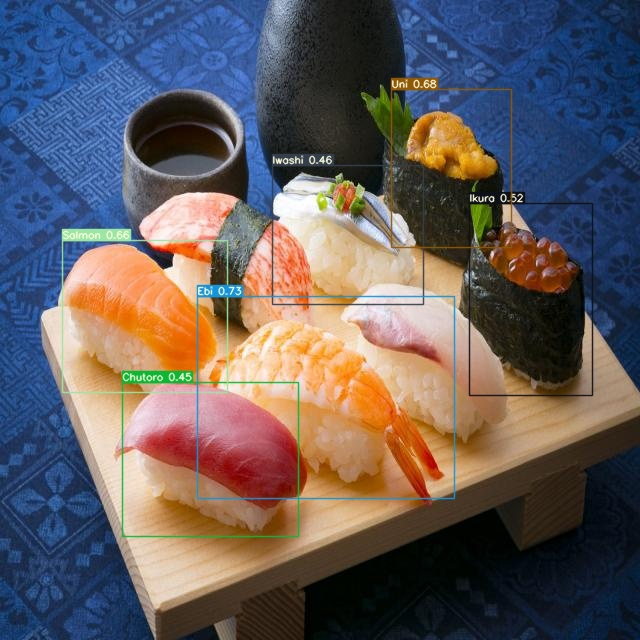

In [11]:
Image("runs/detect/exp/test.jpg")